# AlexNet para classificação do MNIST

Implementação da arquitetura AlexNet adaptada ao conjunto de dados MNIST para treinamento durante 10 épocas e análise dos resultados.

2. Importar bibliotecas

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix
import seaborn as sns

3. Carregar e preparar o MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)
(10000, 28, 28, 1)


4. Criar a AlexNet adaptada

In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 padding='same',
                 input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu',
                 padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu',
                 padding='same'))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

5. Mostrar arquitetura

In [7]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,130 (6.49 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

6. Compilar o modelo

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

7. Treinar por 10 épocas

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 74ms/step - accuracy: 0.9565 - loss: 0.1402 - val_accuracy: 0.9872 - val_loss: 0.0412
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 135s 72ms/step - accuracy: 0.9854 - loss: 0.0506 - val_accuracy: 0.9914 - val_loss: 0.0280
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 136s 73ms/step - accuracy: 0.9895 - loss: 0.0358 - val_accuracy: 0.9922 - val_loss: 0.0237
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 73ms/step - accuracy: 0.9915 - loss: 0.0293 - val_accuracy: 0.9898 - val_loss: 0.0306
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 148s 76ms/step - accuracy: 0.9931 - loss: 0.0228 - val_accuracy: 0.9924 - val_loss: 0.0262
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 73ms/step - accuracy: 0.9942 - loss: 0.0188 - val_accuracy: 0.9926 - val_loss: 0.0255
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 76ms/step - accuracy: 0.9954 - loss: 0.0154 - val_accuracy: 0.9933 - val_loss: 0.0236
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 136s 72ms/step - accuracy: 

8. Mostrar Loss e Accuracy

In [10]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9917 - loss: 0.0370
Loss: 0.03703758865594864
Accuracy: 0.9916999936103821


9. Gráfico de Accuracy

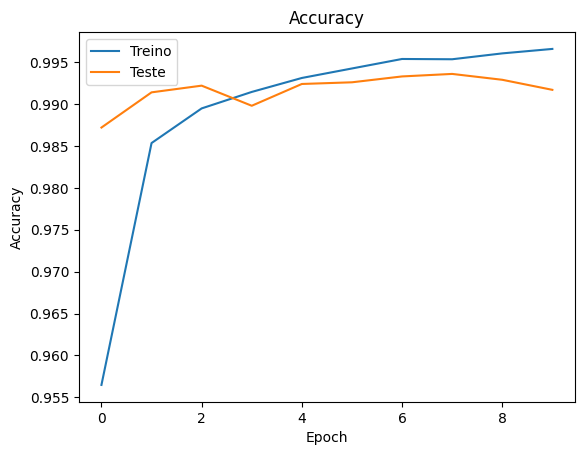

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Teste'])

plt.show()

10. Gráfico de Loss

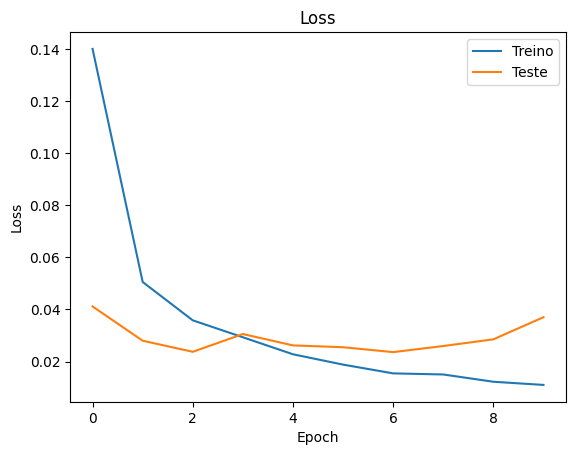

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Teste'])

plt.show()

11. Gerar previsões

In [13]:
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


12. Matriz de confusão

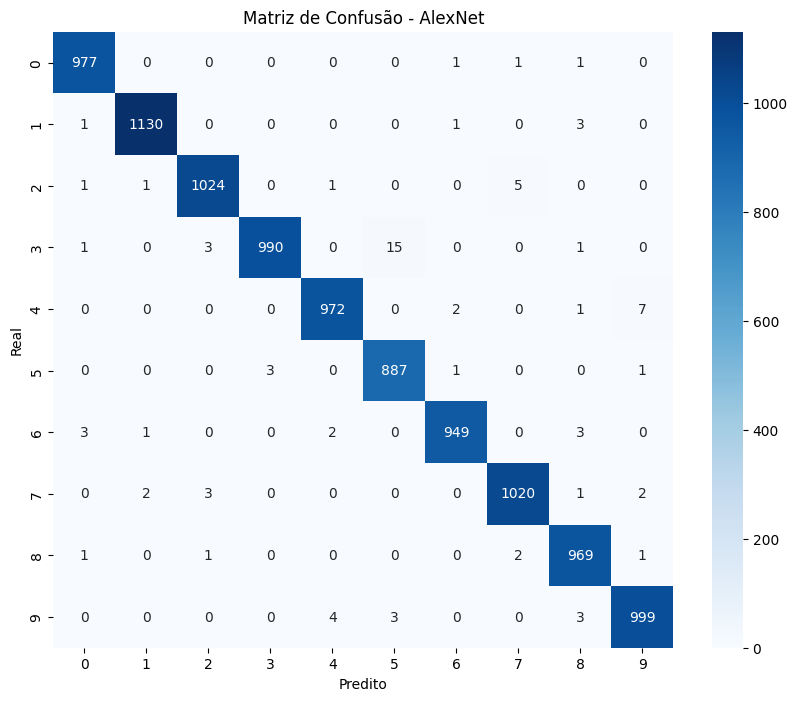

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão - AlexNet')
plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()